# Analysing parameter over groups

In [3]:
# change to the root directory of the project
import os
from pathlib import Path

cwd = Path.cwd()
#or set manual: 
#cwd = '.../ScanDy'

for parent in [cwd] + list(cwd.parents):
    if (parent / "data").exists():
        os.chdir(parent)
        break

print(Path.cwd())

/mnt/raid/data/anina/ScanDy


In [4]:
import importlib
import random

import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns

from neurolib.optimize.evolution import Evolution
from neurolib.utils.parameterSpace import ParameterSpace

import scandy_pfc.models.ObjectModel as objectmodel_module
import scandy_pfc.models.model as base_model
import scandy_pfc.utils.dataclass as dataclass_module

In [5]:
importlib.reload(dataclass_module)
Dataset = dataclass_module.Dataset
importlib.reload(base_model)
importlib.reload(objectmodel_module)
ObjectModel = objectmodel_module.ObjectModel

In [6]:
dircl = ['xkcd:maroon', sns.color_palette("Dark2")[1], sns.color_palette("Dark2")[5], sns.color_palette("Dark2")[6] ]
mcl = ['xkcd:blue', 'xkcd:red']
MODEL = "obj" 
FEATURESET = "bottom_up" 

In [7]:
#Parameters to change for each dataset
#test_group = "young" #"old" "pd_on", "pd_off"
dataframe_files = {
    "young": 'parkinson_data/df_img_fovs_psycsci.csv',
    "old":  'parkinson_data/df_img_fovs_controls.csv',
    "pd_on": 'parkinson_data/df_img_fovs_parkinson_with.csv',
    "pd_off": 'parkinson_data/df_img_fovs_parkinson_without.csv'

}
folder_path = "PictureExample/PictureExample_Resized/picture"

#####
evolution_name_dill = f"randomstart_scale4/evol_par_rand_cb_s10__std0.5_imgseed10"
simulate_with_best_params = f"randomstart_scale4/best_par_rand_cb_s10__std0.5_imgseed10"

In [8]:
# full imagelist
#imglist = sorted(files)
imglist =   ['plank', 'fingerTapping', 'statues', 'work2', 'pedestrian', 'chessBoard', 'youtube', 'axolotl', 'reindeers', 'ballBalance', 'bench', 'birdFalling', 'elevatorEmpty', 'mokaPot', 'toytrainHouses', 'ventilator', 'penDrawing', 'dino', 'trafficLight']

random.seed(12345)
trainlist = sorted(random.sample(imglist, 10))
testlist = sorted([vidname for vidname in imglist if vidname not in trainlist])

VidCom = {}

for key, gt_foveation_df in dataframe_files.items():
    dva = 47.7 if key == "young" else 40.45
    datadict = {
        "PATH": "PictureExample/PictureExample_Resized/",
        'FPS': 30,
        'PX_TO_DVA': ((dva * 0.8) / 1920)*4,
        'FRAMES_ALL_VIDS': 150,
        'VID_EXTENSION' : 'png',
        'gt_foveation_df': gt_foveation_df,
        'dataformat': 'picture', #video
        'NAME_COL': 'scene',
        'trainset': trainlist,
        'testset': testlist,
        'used_videos': imglist
    }
    ds = Dataset(datadict)
    VidCom[key] = ds
    


Video column is set to: scene
Video column is set to: scene
Video column is set to: scene
Video column is set to: scene


In [9]:
#Settings
iterations = 3 #top 3 parameter sets

param_bounds = {
    'ddm_thres': [0.5, 5.0],     
    'ddm_sig': [0.05, 0.45],        
    'att_dva': [4.0, 10.0],     
    'ior_decay': [30, 200],     
    'ior_inobj': [0.4, 1.0]     
}

MainProcess pypet.storageservice.HDF5StorageService INFO     I will use the hdf5 file `./data/hdf/evolution.hdf`.
MainProcess pypet.environment.Environment INFO     Environment initialized.
MainProcess root INFO     Evolution: Using algorithm: adaptive
MainProcess root INFO     Evolution: Individual generation: <function randomParametersAdaptive at 0x7f4f88a7dbd0>
MainProcess root INFO     Evolution: Mating operator: <function cxBlend at 0x7f4f896604c0>
MainProcess root INFO     Evolution: Mutation operator: <function gaussianAdaptiveMutation_nStepSizes at 0x7f4f88a7e050>
MainProcess root INFO     Evolution: Parent selection: <function selRank at 0x7f4f88a7dd80>
MainProcess root INFO     Evolution: Selection operator: <function selBest_multiObj at 0x7f4f88a7de10>
MainProcess root INFO     Assuming parameter kind "bound"
MainProcess root INFO     Assuming parameter kind "bound"
MainProcess root INFO     weightList not set, assuming single fitness value to be maximized.
MainProcess root 

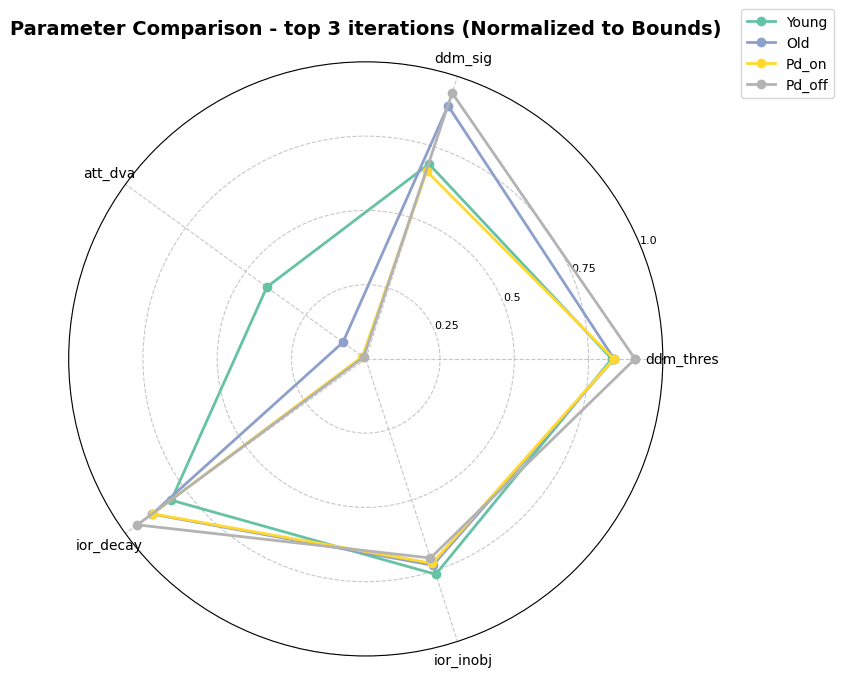

In [10]:
data_list = []
group_names = [g.capitalize() for g in VidCom.keys()]
parameters = ['ddm_thres', 'ddm_sig', 'att_dva', 'ior_decay', 'ior_inobj']
# Convert to arrays
mins = np.array([param_bounds[p][0] for p in parameters])
maxs = np.array([param_bounds[p][1] for p in parameters])

for ax_i, key in enumerate(VidCom.keys()):
    # dummy evol overwritten later
    evol = Evolution(lambda x: x, ParameterSpace(['mock'], [[0, 1]]))
    
    DILLNAME = f'{evolution_name_dill}_{key}.dill'
    model = ObjectModel(VidCom[key])
  

    evol = evol.loadEvolution(f'sorted_results/{DILLNAME}')  # overwrite dummy evol
    df_evol = evol.dfEvolution(outputs=True).copy()
    df_top = df_evol.sort_values('score', ascending=False)[:iterations]

    mean_vals = [df_top[p].mean() for p in parameters]
    data_list.append(mean_vals)

data = np.array(data_list)
norm = (data - mins) / (maxs - mins)

angles = np.linspace(0, 2*np.pi, len(parameters), endpoint=False).tolist()
angles += angles[:1]  

# Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = plt.cm.Set2(np.linspace(0, 1, len(group_names)))

for i, (group_data, name) in enumerate(zip(norm, group_names)):
    vals = np.concatenate((group_data, [group_data[0]]))
    ax.plot(angles, vals, 'o-', linewidth=2, label=name, color=colors[i])

# Styling
ax.set_xticks(angles[:-1])
ax.set_xticklabels(parameters, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], size=8)
ax.set_title(f"Parameter Comparison - top {iterations} iterations (Normalized to Bounds)", 
             size=14, weight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
